# Feature Engineering

This notebook contains runnable versions of the code examples from `Chapter_Feature_Engineering.md`.

The examples use small made-up manufacturing and welding datasets so the notebook can run even when the larger course dataset is not available. Run the cells from top to bottom so shared variables like `df`, `X_train`, `y_train`, and `feature_names` are created before later examples use them.

## Setup

This cell imports the libraries used throughout the examples. Optional examples such as SMOTE and UMAP are skipped with a clear message if the extra package is not installed.

In [1]:
%matplotlib inline

import importlib.util

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelBinarizer, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.utils import resample


def package_is_available(package_name):
    return importlib.util.find_spec(package_name) is not None


print('Ready for feature engineering examples.')

Ready for feature engineering examples.


## Categorical and continuous variables

This example creates a small inspection table with categorical fields, continuous measurements, dates, and labels.

In [2]:
df = pd.DataFrame({
    'weld_id': ['W001', 'W002', 'W003', 'W004', 'W005', 'W006', 'W007', 'W008'],
    'material': ['steel', 'alloy', 'steel', 'titanium', 'alloy', 'steel', 'titanium', 'steel'],
    'risk_level': ['low', 'medium', 'low', 'high', 'medium', 'low', 'high', 'medium'],
    'inspection_result': ['pass', 'fail', 'pass', 'fail', 'pass', 'pass', 'fail', 'pass'],
    'operator_birthdate': ['1988-04-12', '1976-09-03', '1992-01-25', '1985-07-19', '1990-11-02', '1982-06-01', '1979-12-15', '1994-03-20'],
    'inspection_date': ['2026-04-26'] * 8,
    'weld_length_mm': [42.5, 38.0, 51.2, 46.0, 39.5, 44.3, 48.8, 41.0],
    'temperature_c': [880, 910, 895, 940, 900, 875, 950, 890],
    'defect_width_mm': [0.0, 2.0, 0.0, 5.5, 1.2, 0.0, 4.8, 0.5],
    'defect_height_mm': [0.0, 1.5, 0.0, 2.0, 0.8, 0.0, 3.0, 0.4],
    'defect_class': ['no_defect', 'porosity', 'no_defect', 'crack', 'porosity', 'no_defect', 'crack', 'no_defect'],
})

categorical_columns = ['material', 'risk_level', 'inspection_result', 'defect_class']
continuous_columns = ['weld_length_mm', 'temperature_c', 'defect_width_mm', 'defect_height_mm']

print('Categorical columns:', categorical_columns)
print('Continuous columns:', continuous_columns)
df

Categorical columns: ['material', 'risk_level', 'inspection_result', 'defect_class']
Continuous columns: ['weld_length_mm', 'temperature_c', 'defect_width_mm', 'defect_height_mm']


,weld_id,material,risk_level,inspection_result,operator_birthdate,inspection_date,weld_length_mm,temperature_c,defect_width_mm,defect_height_mm,defect_class
0,W001,steel,low,pass,1988-04-12,2026-04-26,42.5,880,0.0,0.0,no_defect
1,W002,alloy,medium,fail,1976-09-03,2026-04-26,38.0,910,2.0,1.5,porosity
2,W003,steel,low,pass,1992-01-25,2026-04-26,51.2,895,0.0,0.0,no_defect
3,W004,titanium,high,fail,1985-07-19,2026-04-26,46.0,940,5.5,2.0,crack
4,W005,alloy,medium,pass,1990-11-02,2026-04-26,39.5,900,1.2,0.8,porosity
5,W006,steel,low,pass,1982-06-01,2026-04-26,44.3,875,0.0,0.0,no_defect
6,W007,titanium,high,fail,1979-12-15,2026-04-26,48.8,950,4.8,3.0,crack
7,W008,steel,medium,pass,1994-03-20,2026-04-26,41.0,890,0.5,0.4,no_defect


## Creating new features from existing fields

This section calculates age from birthdate, defect area from width and height, and temperature range from maximum and minimum values.

In [3]:
df['operator_birthdate'] = pd.to_datetime(df['operator_birthdate'])
df['inspection_date'] = pd.to_datetime(df['inspection_date'])

age_days = df['inspection_date'] - df['operator_birthdate']
df['operator_age'] = (age_days.dt.days / 365.25).astype(int)
df['defect_area_mm2'] = df['defect_width_mm'] * df['defect_height_mm']

# A small process table for the temperature-range example.
process_df = pd.DataFrame({
    'max_temperature_c': [925, 940, 910],
    'min_temperature_c': [870, 880, 865],
})
process_df['temperature_range_c'] = process_df['max_temperature_c'] - process_df['min_temperature_c']

print(df[['operator_birthdate', 'operator_age', 'defect_width_mm', 'defect_height_mm', 'defect_area_mm2']])
print(process_df)

  operator_birthdate  operator_age  defect_width_mm  defect_height_mm  \
0         1988-04-12            38              0.0               0.0   
1         1976-09-03            49              2.0               1.5   
2         1992-01-25            34              0.0               0.0   
3         1985-07-19            40              5.5               2.0   
4         1990-11-02            35              1.2               0.8   
5         1982-06-01            43              0.0               0.0   
6         1979-12-15            46              4.8               3.0   
7         1994-03-20            32              0.5               0.4   

   defect_area_mm2  
0             0.00  
1             3.00  
2             0.00  
3            11.00  
4             0.96  
5             0.00  
6            14.40  
7             0.20  
   max_temperature_c  min_temperature_c  temperature_range_c
0                925                870                   55
1                940           

## Encoding categorical variables

Nominal categories can be converted with one-hot encoding. True ordinal categories can use a documented ordered mapping.

In [4]:
risk_map = {
    'low': 0,
    'medium': 1,
    'high': 2,
}

encoded_df = pd.get_dummies(df, columns=['material'], dtype=int)
encoded_df['risk_level_encoded'] = encoded_df['risk_level'].map(risk_map)
encoded_df['inspection_failed'] = (encoded_df['inspection_result'] == 'fail').astype(int)

print(encoded_df[['weld_id', 'material_alloy', 'material_steel', 'material_titanium', 'risk_level', 'risk_level_encoded', 'inspection_failed']])

  weld_id  material_alloy  material_steel  material_titanium risk_level  \
0    W001               0               1                  0        low   
1    W002               1               0                  0     medium   
2    W003               0               1                  0        low   
3    W004               0               0                  1       high   
4    W005               1               0                  0     medium   
5    W006               0               1                  0        low   
6    W007               0               0                  1       high   
7    W008               0               1                  0     medium   

   risk_level_encoded  inspection_failed  
0                   0                  0  
1                   1                  1  
2                   0                  0  
3                   2                  1  
4                   1                  0  
5                   0                  0  
6                   2  

## Scaling numeric values

This section demonstrates min-max scaling, standard scaling, robust scaling, and the train/test pattern for fitting scalers.

In [5]:
minmax_scaler = MinMaxScaler()
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

scaling_df = df[['weld_length_mm', 'temperature_c', 'defect_area_mm2']].copy()
scaling_df['weld_length_minmax'] = minmax_scaler.fit_transform(scaling_df[['weld_length_mm']])
scaling_df['temperature_standard'] = standard_scaler.fit_transform(scaling_df[['temperature_c']])
scaling_df['defect_area_robust'] = robust_scaler.fit_transform(scaling_df[['defect_area_mm2']])

print(scaling_df)

feature_columns = ['weld_length_mm', 'temperature_c', 'defect_area_mm2', 'operator_age']
X = df[feature_columns]
y = df['defect_class']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.375,
    random_state=42,
    stratify=y,
)

train_scaler = StandardScaler()
X_train_scaled = train_scaler.fit_transform(X_train)
X_test_scaled = train_scaler.transform(X_test)

print('X_train_scaled shape:', X_train_scaled.shape)
print('X_test_scaled shape:', X_test_scaled.shape)

   weld_length_mm  temperature_c  defect_area_mm2  weld_length_minmax  \
0            42.5            880             0.00            0.340909   
1            38.0            910             3.00            0.000000   
2            51.2            895             0.00            1.000000   
3            46.0            940            11.00            0.606061   
4            39.5            900             0.96            0.113636   
5            44.3            875             0.00            0.477273   
6            48.8            950            14.40            0.818182   
7            41.0            890             0.20            0.227273   

   temperature_standard  defect_area_robust  
0             -0.985329              -0.116  
1              0.197066               0.484  
2             -0.394132              -0.116  
3              1.379461               2.084  
4             -0.197066               0.076  
5             -1.182395              -0.116  
6              1.773

## Transforming size, shape, and label type

Models expect specific input shapes. Tabular data is usually two-dimensional, labels are often one-dimensional, and images may require height, width, and channel dimensions.

In [6]:
X_array = np.array([
    [42.5, 880],
    [38.0, 910],
    [51.2, 895],
])
y_array = np.array(['no_defect', 'porosity', 'crack'])

print('Tabular X shape:', X_array.shape)
print('Label y shape:', y_array.shape)

weld_lengths = np.array([42.5, 38.0, 51.2])
print('One feature before reshape:', weld_lengths.shape)
print('One feature after reshape:', weld_lengths.reshape(-1, 1).shape)

sample_image = np.arange(224 * 224, dtype=float).reshape(224, 224)
sample_image = sample_image / sample_image.max()
sample_image_with_channel = sample_image.reshape(224, 224, 1)
print('Image shape with channel:', sample_image_with_channel.shape)

encoder = LabelBinarizer()
y_one_hot = encoder.fit_transform(['no_defect', 'porosity', 'crack', 'no_defect'])
print('One-hot labels:')
print(y_one_hot)

Tabular X shape: (3, 2)
Label y shape: (3,)
One feature before reshape: (3,)
One feature after reshape: (3, 1)
Image shape with channel: (224, 224, 1)
One-hot labels:
[[0 1 0]
 [0 0 1]
 [1 0 0]
 [0 1 0]]


## Rebalancing classes

This section demonstrates class counts, oversampling, undersampling, optional SMOTE, class weights, and threshold adjustment.

In [7]:
imbalanced_df = pd.DataFrame({
    'feature_value': np.arange(20),
    'defect_class': ['no_defect'] * 15 + ['crack'] * 3 + ['porosity'] * 2,
})

print('Original class counts:')
print(imbalanced_df['defect_class'].value_counts())

majority = imbalanced_df[imbalanced_df['defect_class'] == 'no_defect']
minority = imbalanced_df[imbalanced_df['defect_class'] == 'crack']

minority_oversampled = resample(
    minority,
    replace=True,
    n_samples=len(majority),
    random_state=42,
)
oversampled_df = pd.concat([majority, minority_oversampled])
print('\nOversampled no_defect/crack counts:')
print(oversampled_df['defect_class'].value_counts())

majority_undersampled = resample(
    majority,
    replace=False,
    n_samples=len(minority),
    random_state=42,
)
undersampled_df = pd.concat([majority_undersampled, minority])
print('\nUndersampled no_defect/crack counts:')
print(undersampled_df['defect_class'].value_counts())

if package_is_available('imblearn'):
    from imblearn.over_sampling import SMOTE

    smote = SMOTE(random_state=42, k_neighbors=1)
    X_small = np.array([[0], [1], [2], [3], [4], [5], [20], [22]])
    y_small = np.array(['no_defect'] * 6 + ['crack'] * 2)
    X_resampled, y_resampled = smote.fit_resample(X_small, y_small)
    print('\nSMOTE counts:')
    print(pd.Series(y_resampled).value_counts())
else:
    print('\nSMOTE example skipped because imbalanced-learn is not installed.')

binary_X = np.array([[0.1], [0.2], [0.4], [1.0], [1.2], [1.5], [3.0], [3.5]])
binary_y = np.array([0, 0, 0, 0, 0, 0, 1, 1])
weighted_model = LogisticRegression(class_weight='balanced').fit(binary_X, binary_y)
probabilities = weighted_model.predict_proba(binary_X)[:, 1]
threshold_predictions = probabilities >= 0.30
print('\nThreshold predictions:', threshold_predictions.astype(int))

Original class counts:
defect_class
no_defect    15
crack         3
porosity      2
Name: count, dtype: int64

Oversampled no_defect/crack counts:
defect_class
no_defect    15
crack        15
Name: count, dtype: int64

Undersampled no_defect/crack counts:
defect_class
no_defect    3
crack        3
Name: count, dtype: int64

SMOTE example skipped because imbalanced-learn is not installed.

Threshold predictions: [0 0 0 0 0 1 1 1]


## Identifying and selecting important features

Feature importance is evidence, not final truth. Combine it with domain knowledge, leakage checks, and stakeholder review.

In [8]:
model_df = encoded_df.copy()
model_features = [
    'weld_length_mm',
    'temperature_c',
    'defect_area_mm2',
    'operator_age',
    'material_alloy',
    'material_steel',
    'material_titanium',
    'risk_level_encoded',
]

feature_names = model_features
X_model = model_df[feature_names]
y_model = (model_df['defect_class'] != 'no_defect').astype(int)

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_model, y_model)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_,
}).sort_values('importance', ascending=False)
print(importance_df)

permutation = permutation_importance(
    rf_model,
    X_model,
    y_model,
    n_repeats=10,
    random_state=42,
)
permutation_df = pd.DataFrame({
    'feature': feature_names,
    'importance': permutation.importances_mean,
}).sort_values('importance', ascending=False)
print('\nPermutation importance:')
print(permutation_df)

columns_to_drop = ['operator_birthdate', 'inspection_date', 'inspection_result']
selected_X = df.drop(columns=columns_to_drop + ['defect_class'])
print('\nSelected columns after dropping leakage/sensitive/raw fields:')
print(selected_X.columns.tolist())

              feature  importance
2     defect_area_mm2    0.290063
1       temperature_c    0.230825
5      material_steel    0.229397
7  risk_level_encoded    0.094381
0      weld_length_mm    0.062222
4      material_alloy    0.052667
3        operator_age    0.034889
6   material_titanium    0.005556

Permutation importance:
              feature  importance
0      weld_length_mm         0.0
1       temperature_c         0.0
2     defect_area_mm2         0.0
3        operator_age         0.0
4      material_alloy         0.0
5      material_steel         0.0
6   material_titanium         0.0
7  risk_level_encoded         0.0

Selected columns after dropping leakage/sensitive/raw fields:
['weld_id', 'material', 'risk_level', 'weld_length_mm', 'temperature_c', 'defect_width_mm', 'defect_height_mm', 'operator_age', 'defect_area_mm2']


## Dimensionality reduction

PCA, t-SNE, and UMAP can help reduce or visualize high-dimensional data. PCA is usually more directly repeatable for future data; t-SNE and UMAP are commonly used for exploration.

PCA shape: (80, 2)
PCA explained variance ratio: [0.23521966 0.11926801]


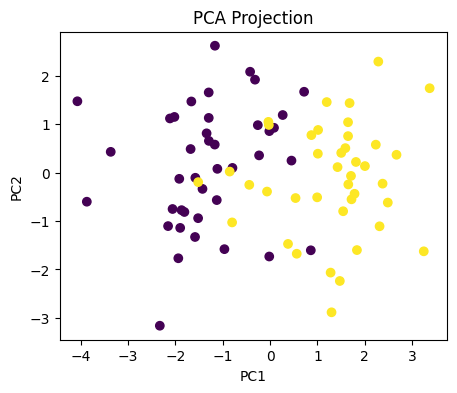

t-SNE shape: (80, 2)


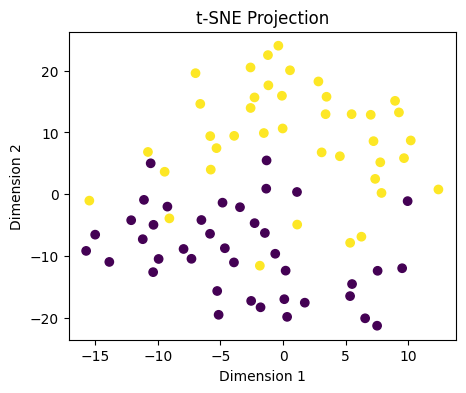

UMAP example skipped because umap-learn is not installed.


In [9]:
rng = np.random.default_rng(42)
X_high_dimensional = rng.normal(size=(80, 12))
X_high_dimensional[:, 1] = X_high_dimensional[:, 0] * 0.8 + rng.normal(scale=0.2, size=80)
cluster_labels = np.array(['group_a'] * 40 + ['group_b'] * 40)
X_high_dimensional[40:, :3] += 2.0

X_scaled_for_reduction = StandardScaler().fit_transform(X_high_dimensional)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_for_reduction)
print('PCA shape:', X_pca.shape)
print('PCA explained variance ratio:', pca.explained_variance_ratio_)

plt.figure(figsize=(5, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=(cluster_labels == 'group_b'))
plt.title('PCA Projection')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='random', learning_rate='auto')
X_tsne = tsne.fit_transform(X_scaled_for_reduction)
print('t-SNE shape:', X_tsne.shape)

plt.figure(figsize=(5, 4))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=(cluster_labels == 'group_b'))
plt.title('t-SNE Projection')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.show()

if package_is_available('umap'):
    import umap

    reducer = umap.UMAP(n_components=2, random_state=42)
    X_umap = reducer.fit_transform(X_scaled_for_reduction)
    print('UMAP shape:', X_umap.shape)

    plt.figure(figsize=(5, 4))
    plt.scatter(X_umap[:, 0], X_umap[:, 1], c=(cluster_labels == 'group_b'))
    plt.title('UMAP Projection')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.show()
else:
    print('UMAP example skipped because umap-learn is not installed.')